# Análisis de Capacidad de Proceso — Cpk

Calculamos el índice Cpk para cada producto usando los datos de
inspección dimensional. Cpk ≥ 1.33 indica proceso capaz (estándar
industrial automotriz).

In [14]:
import pandas as pd
import numpy as np
from pathlib import Path

ruta_datos = Path("../data/raw/dataset_automotriz")

inspeccion = pd.read_csv(ruta_datos / "fact_inspeccion_calidad.csv", 
                          parse_dates=["fecha"])

print(f"Registros: {len(inspeccion):,}")
print(f"Columnas: {inspeccion.columns.tolist()}")

Registros: 22,315
Columnas: ['id_inspeccion', 'id_produccion', 'id_producto', 'id_maquina', 'id_linea', 'fecha', 'id_turno', 'id_operador', 'n_muestra', 'dimension_medida_mm', 'lsl_mm', 'usl_mm', 'target_mm', 'dentro_especificacion', 'inspector']


In [15]:
def calcular_cpk(grupo):
    media = grupo['dimension_medida_mm'].mean()
    sigma = grupo['dimension_medida_mm'].std()
    lsl = grupo['lsl_mm'].iloc[0]
    usl = grupo['usl_mm'].iloc[0]
    
    if sigma == 0:
        return np.nan
    
    cpu = (usl - media) / (3 * sigma)
    cpl = (media - lsl) / (3 * sigma)
    cpk = min(cpu, cpl)
    
    return round(cpk, 3)

cpk_por_producto = (
    inspeccion
    .groupby('id_producto')
    .apply(calcular_cpk)
    .reset_index()
    .rename(columns={0: 'cpk'})
    .sort_values('cpk', ascending=True)
)

cpk_por_producto

,id_producto,cpk
6,SKU-AUTO-007,0.806
1,SKU-AUTO-002,1.114
0,SKU-AUTO-001,1.121
2,SKU-AUTO-003,1.122
3,SKU-AUTO-004,1.123
4,SKU-AUTO-005,1.130
7,SKU-AUTO-008,1.137
5,SKU-AUTO-006,1.169


### Investigación: SKU-AUTO-007 con Cpk crítico (0.806)

SKU-AUTO-007 es el único producto con Cpk < 1.0 (proceso incapaz).
Investigamos si el problema está concentrado en alguna máquina específica.

In [16]:
sku007 = inspeccion[inspeccion['id_producto'] == 'SKU-AUTO-007']
cpk_por_maquina_SKU_AUTO_007 = (
    sku007
    .groupby('id_maquina')
    .apply(calcular_cpk)
    .reset_index()
    .rename(columns={0: 'cpk'})
    .sort_values('cpk', ascending=True)
)

cpk_por_maquina_SKU_AUTO_007

,id_maquina,cpk
3,M04,0.637
2,M03,0.649
0,M01,1.118
1,M02,1.190


### Conclusión — Análisis Cpk

El SKU-AUTO-007 producido en M03 y M04 presenta Cpk crítico 
(0.637 y 0.649) — proceso gravemente incapaz que genera piezas 
fuera de especificación de forma sistemática.

M03 acumula dos alertas críticas:
- OEE más bajo de la planta (~90.85%)
- Cpk < 0.7 en SKU-AUTO-007

Recomendación: revisar inmediatamente en M03 — revisión de 
herramental, recalibración y análisis de causa raíz específico 
para la combinación M03 × SKU-AUTO-007.

## Visualización: Cpk por producto

Barras de Cpk por producto con líneas de referencia en 1.33 (mínimo 
aceptable en automotriz) y 1.67 (proceso muy capaz).

In [18]:
import matplotlib.pyplot as plt

productos = cpk_por_producto['id_producto'].tolist()
valores_cpk = cpk_por_producto['cpk'].tolist()

print(productos)
print(valores_cpk)
colores = ['tomato' if cpk < 1.33 else 'steelblue' for cpk in valores_cpk]
print(colores)

['SKU-AUTO-007', 'SKU-AUTO-002', 'SKU-AUTO-001', 'SKU-AUTO-003', 'SKU-AUTO-004', 'SKU-AUTO-005', 'SKU-AUTO-008', 'SKU-AUTO-006']
[0.806, 1.114, 1.121, 1.122, 1.123, 1.13, 1.137, 1.169]
['tomato', 'tomato', 'tomato', 'tomato', 'tomato', 'tomato', 'tomato', 'tomato']


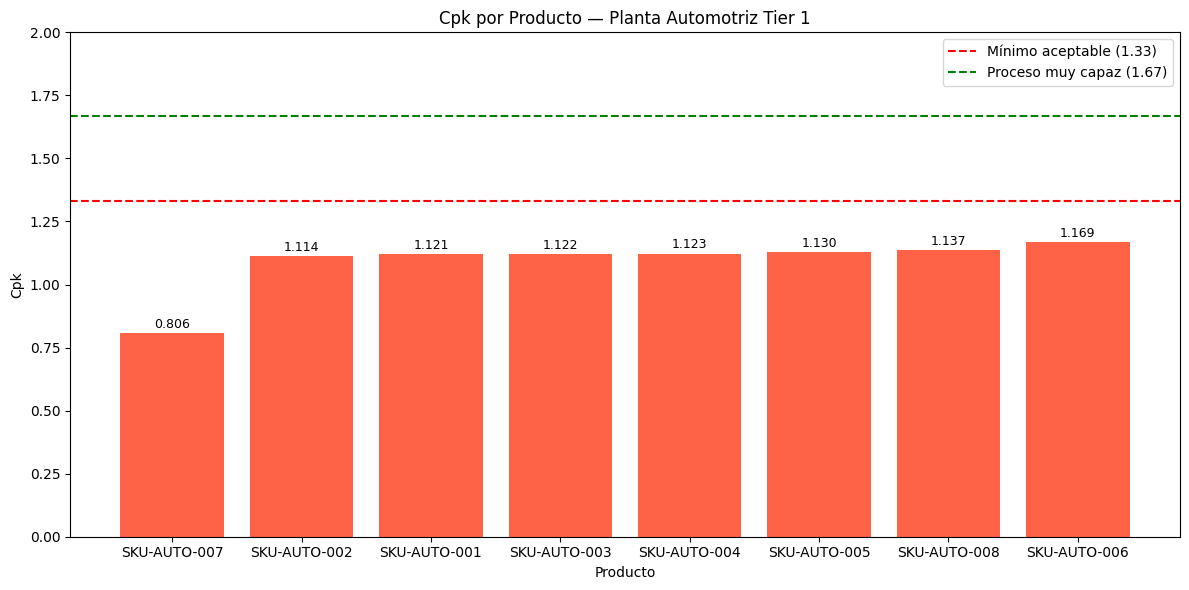

In [22]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(productos, valores_cpk, color=colores)

for bar, valor in zip(ax.patches, valores_cpk):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{valor:.3f}",
        ha='center',
        fontsize=9
    )
ax.axhline(y=1.33, color='red', linestyle='--', linewidth=1.5, label='Mínimo aceptable (1.33)')
ax.axhline(y=1.67, color='green', linestyle='--', linewidth=1.5, label='Proceso muy capaz (1.67)')

ax.set_title("Cpk por Producto — Planta Automotriz Tier 1")
ax.set_xlabel("Producto")
ax.set_ylabel("Cpk")
ax.set_ylim(0, 2)
ax.legend()

plt.tight_layout()
plt.show()